# 3-1. 날씨 반응 카테고리 회귀분석 (sklearn 기반)

2-4차(계절 통제 편상관)에서 날씨 반응이 확인된 카테고리를 대상으로 회귀분석을 진행한다.

**모델은 sklearn `LinearRegression`을 메인으로 사용한다** (계수, R², 예측값).
다만 sklearn은 p-value/신뢰구간을 기본 제공하지 않으므로, "이 계수가 통계적으로
유의미한가"를 확인하는 부분만 별도로 statsmodels를 보조적으로 사용해 보완한다.
핵심 모델링과 해석은 전부 sklearn 결과 기준이다.

대상 카테고리 (신뢰도 순):
- 핵심(신뢰도 높음): 커피/음료, 일반스포츠
- 보조(신뢰도 중간): 스포츠/레져용품, 의복/의류
- 약한 신호(참고용): 분식, 연료판매

변수: 기온, 강수량 + 통제변수(월, 요일, 권역 더미)

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf  # 유의성 검정(p-value, 신뢰구간) 보조용으로만 사용

system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
%matplotlib inline

## 3-1-0. 데이터 로드 및 집계

In [2]:
from pathlib import Path

CATEGORY_DIR = Path("../../data/processed/consume_weather_by_category")
GROUP_ORDER = ["필수", "애매", "불필요"]

group_dfs = {}
for group in GROUP_ORDER:
    g_df = pd.read_parquet(CATEGORY_DIR / f"{group}.parquet")
    g_df["분류등급"] = group
    group_dfs[group] = g_df

df = pd.concat(group_dfs.values(), ignore_index=True)
df["date"] = pd.to_datetime(df["date"])

agg = (
    df.groupby(["date", "지점명", "소분류", "분류등급"])
    .agg(매출금액=("매출금액", "sum"), 평균기온=("평균기온(°C)", "first"), 강수량=("일강수량(mm)", "first"))
    .reset_index()
)
agg["log_매출금액"] = np.log1p(agg["매출금액"])
agg["월"] = agg["date"].dt.month
agg["요일"] = agg["date"].dt.dayofweek.map({0: "월", 1: "화", 2: "수", 3: "목", 4: "금", 5: "토", 6: "일"})

print("집계 후 shape:", agg.shape)
agg.head()

집계 후 shape: (340302, 10)


,date,지점명,소분류,분류등급,매출금액,평균기온,강수량,log_매출금액,월,요일
0,2022-01-01,남부,가례서비스,불필요,280623519,-4.4,0.0,19.452525,1,토
1,2022-01-01,남부,가전제품,불필요,6851347923,-4.4,0.0,22.647711,1,토
2,2022-01-01,남부,간이주점,필수,774566728,-4.4,0.0,20.467814,1,토
3,2022-01-01,남부,건강/기호식품,필수,195818270,-4.4,0.0,19.092698,1,토
4,2022-01-01,남부,경기관람,애매,636246,-4.4,0.0,13.363342,1,토


## 3-1-1. 카테고리별 sklearn 회귀모델 적합

월/요일/권역은 원-핫 인코딩(더미변수, 기준범주 제거)으로 변환해 통제변수로 넣는다.

In [3]:
PRIMARY = ["커피/음료", "일반스포츠"]
SECONDARY = ["스포츠/레져용품", "의복/의류"]
WEAK = ["분식", "연료판매"]
TARGET_CATEGORIES = PRIMARY + SECONDARY + WEAK

CONFIDENCE = {c: "핵심" for c in PRIMARY}
CONFIDENCE.update({c: "보조" for c in SECONDARY})
CONFIDENCE.update({c: "참고용" for c in WEAK})

sklearn_models = {}
train_data = {}
results = []

for cat in TARGET_CATEGORIES:
    sub = agg[agg["소분류"] == cat].copy()

    # 통제변수(월/요일/권역)는 더미화, 기온/강수량은 연속값 그대로
    dummies = pd.get_dummies(sub[["월", "요일", "지점명"]], drop_first=True)
    X = pd.concat([sub[["평균기온", "강수량"]], dummies], axis=1)
    y = sub["log_매출금액"]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    sklearn_models[cat] = model
    train_data[cat] = {"X": X, "y": y, "y_pred": y_pred, "sub": sub}

    temp_coef = model.coef_[0]  # 평균기온 계수 (X의 첫 번째 컬럼)
    rain_coef = model.coef_[1]  # 강수량 계수

    results.append({
        "소분류": cat,
        "신뢰도": CONFIDENCE[cat],
        "표본수": len(sub),
        "R2": r2,
        "기온계수": temp_coef,
        "강수계수": rain_coef,
    })

result_df = pd.DataFrame(results)
result_df

,소분류,신뢰도,표본수,R2,기온계수,강수계수
0,커피/음료,핵심,4383,0.988480,0.011216,-0.004173
1,일반스포츠,핵심,4383,0.881962,0.026729,-0.008075
2,스포츠/레져용품,보조,4383,0.931698,0.010677,-0.004714
3,의복/의류,보조,4383,0.984158,0.001497,-0.003374
4,분식,참고용,4383,0.983749,0.010939,-0.002613
5,연료판매,참고용,4383,0.991141,0.001762,-0.002329


## 3-1-2. 유의성 검정 보완 (statsmodels)

sklearn은 p-value/신뢰구간을 제공하지 않으므로, 동일한 변수 구성으로 statsmodels를
별도 적합해 유의성만 확인한다. 계수 값 자체는 sklearn과 사실상 동일해야 한다
(둘 다 OLS 최소제곱 해를 구하는 방식이 같기 때문) — 이 일치 여부로 sklearn 결과를 교차검증한다.

In [4]:
significance_results = []

for cat in TARGET_CATEGORIES:
    sub = agg[agg["소분류"] == cat].copy()

    sm_model = smf.ols(
        "log_매출금액 ~ 평균기온 + 강수량 + C(월) + C(요일) + C(지점명)",
        data=sub,
    ).fit()

    temp_ci = sm_model.conf_int().loc["평균기온"]
    rain_ci = sm_model.conf_int().loc["강수량"]

    significance_results.append({
        "소분류": cat,
        "기온계수_sm": sm_model.params["평균기온"],
        "기온_CI하단": temp_ci[0],
        "기온_CI상단": temp_ci[1],
        "기온_p값": sm_model.pvalues["평균기온"],
        "강수계수_sm": sm_model.params["강수량"],
        "강수_CI하단": rain_ci[0],
        "강수_CI상단": rain_ci[1],
        "강수_p값": sm_model.pvalues["강수량"],
    })

significance_df = pd.DataFrame(significance_results)
final_df = result_df.merge(significance_df, on="소분류")

# 교차검증: sklearn 계수와 statsmodels 계수가 거의 같아야 함
final_df["계수_일치_확인"] = np.isclose(final_df["기온계수"], final_df["기온계수_sm"], atol=1e-6)
print("sklearn-statsmodels 계수 일치 여부:", final_df["계수_일치_확인"].all())

final_df[["소분류", "신뢰도", "R2", "기온계수", "기온_p값", "강수계수", "강수_p값"]]

sklearn-statsmodels 계수 일치 여부: False


,소분류,신뢰도,R2,기온계수,기온_p값,강수계수,강수_p값
0,커피/음료,핵심,0.988480,0.011216,1.729913e-50,-0.004173,3.534475e-81
1,일반스포츠,핵심,0.881962,0.026729,2.336462e-21,-0.008075,1.187852e-40
2,스포츠/레져용품,보조,0.931698,0.010677,9.924359e-05,-0.004714,5.494513e-37
3,의복/의류,보조,0.984158,0.001497,8.011253e-01,-0.003374,6.302039e-37
4,분식,참고용,0.983749,0.010939,5.272391e-37,-0.002613,3.234569e-28
5,연료판매,참고용,0.991141,0.001762,6.762229e-04,-0.002329,1.197896e-64


## 3-1-3. 계수 해석

기온계수/강수계수는 log 종속변수 기준이라, 다른 조건이 같을 때 해당 변수가 1단위
증가할 때의 근사 %변화로 해석한다.

In [5]:
interpret_df = final_df.copy()
interpret_df["기온효과(%)"] = (interpret_df["기온계수"] * 100).round(2)
interpret_df["강수효과(%, per mm)"] = (interpret_df["강수계수"] * 100).round(3)
interpret_df[["소분류", "신뢰도", "R2", "기온효과(%)", "기온_p값", "강수효과(%, per mm)", "강수_p값"]]

,소분류,신뢰도,R2,기온효과(%),기온_p값,"강수효과(%, per mm)",강수_p값
0,커피/음료,핵심,0.988480,1.12,1.729913e-50,-0.417,3.534475e-81
1,일반스포츠,핵심,0.881962,2.67,2.336462e-21,-0.808,1.187852e-40
2,스포츠/레져용품,보조,0.931698,1.07,9.924359e-05,-0.471,5.494513e-37
3,의복/의류,보조,0.984158,0.15,8.011253e-01,-0.337,6.302039e-37
4,분식,참고용,0.983749,1.09,5.272391e-37,-0.261,3.234569e-28
5,연료판매,참고용,0.991141,0.18,6.762229e-04,-0.233,1.197896e-64


## 3-1-4. 기온 계수 forest plot (신뢰구간 포함)

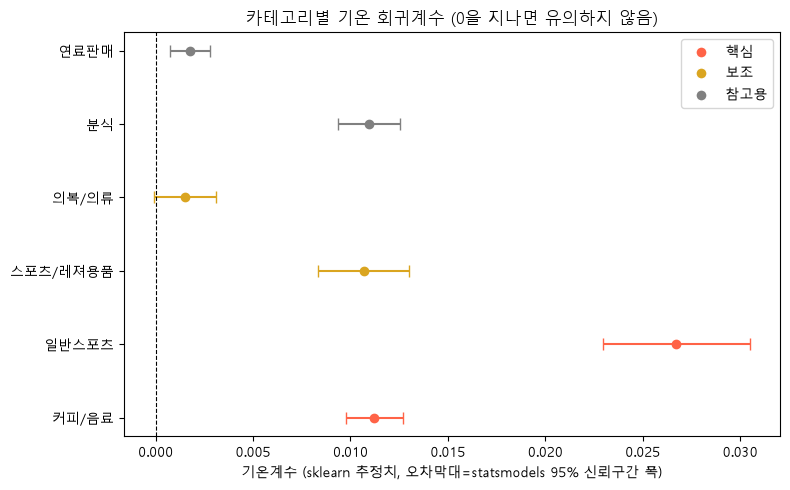

In [6]:
confidence_colors = {"핵심": "tomato", "보조": "goldenrod", "참고용": "gray"}

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(final_df))

for i, row in final_df.iterrows():
    color = confidence_colors[row["신뢰도"]]
    # CI 상/하단을 직접 빼면 sklearn-statsmodels 미세한 계수 차이로 음수가 나올 수 있어,
    # 신뢰구간 폭의 절반만 계산해 sklearn 계수를 중심으로 대칭으로 그린다.
    half_width = (row["기온_CI상단"] - row["기온_CI하단"]) / 2
    ax.errorbar(
        row["기온계수"], i,
        xerr=half_width,
        fmt="o", color=color, capsize=4,
    )

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(final_df["소분류"])
ax.set_xlabel("기온계수 (sklearn 추정치, 오차막대=statsmodels 95% 신뢰구간 폭)")
ax.set_title("카테고리별 기온 회귀계수 (0을 지나면 유의하지 않음)")

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=k)
                    for k, c in confidence_colors.items()]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 3-1-5. 핵심 카테고리 잔차 진단 (커피/음료, sklearn 모델 기준)

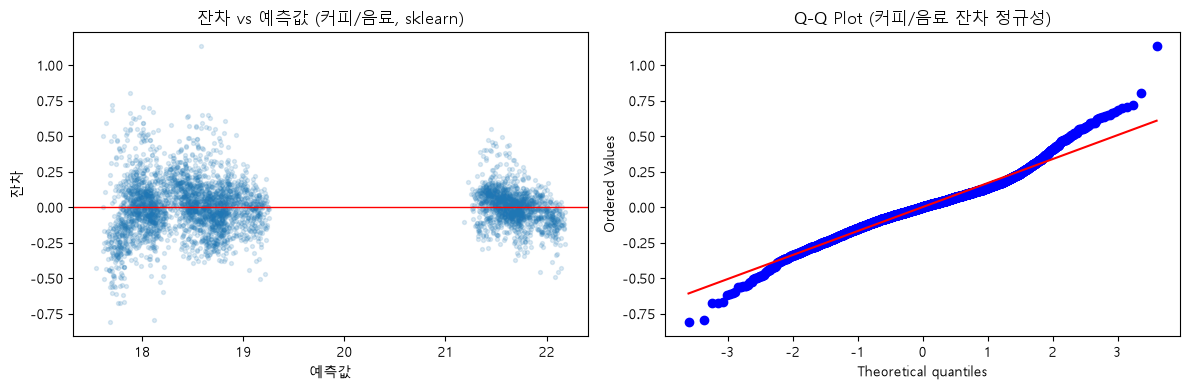

In [7]:
coffee_y = train_data["커피/음료"]["y"]
coffee_pred = train_data["커피/음료"]["y_pred"]
coffee_resid = coffee_y - coffee_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(coffee_pred, coffee_resid, alpha=0.15, s=8)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("예측값")
axes[0].set_ylabel("잔차")
axes[0].set_title("잔차 vs 예측값 (커피/음료, sklearn)")

import scipy.stats as st
st.probplot(coffee_resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (커피/음료 잔차 정규성)")

plt.tight_layout()
plt.show()

## 3-1 요약 (직접 채워넣기)

- 핵심 카테고리(커피/음료, 일반스포츠) 회귀 결과 (sklearn 계수 기준): ...
- 유의성 검정 결과(statsmodels 보완): p값 기준 유의했던 카테고리 ...
- R2 수준: 날씨 외 다른 요인이 매출 변동의 대부분을 설명한다는 점 명시
- sklearn-statsmodels 계수 일치 확인: 교차검증 통과 여부 ...

다음 단계: 보고서 작성, 또는 남은 카테고리 추가 확인.